In [4]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\surai\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\surai\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\surai\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [6]:
#dataset
df=pd.read_csv(r"C:\Users\surai\OneDrive\Attachments\Desktop\MiniProject\Depression-Twitter.csv")
df.head()

,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1
3,3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,RT @SewHQ: #Retro bears make perfect gifts and...,1013187241,84,211,251,837,2,1
4,4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,It’s hard to say whether packing lists are mak...,1013187241,84,211,251,837,1,1


In [7]:

df.shape

(20000, 11)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    20000 non-null  int64 
 1   post_id       20000 non-null  int64 
 2   post_created  20000 non-null  object
 3   post_text     20000 non-null  object
 4   user_id       20000 non-null  int64 
 5   followers     20000 non-null  int64 
 6   friends       20000 non-null  int64 
 7   favourites    20000 non-null  int64 
 8   statuses      20000 non-null  int64 
 9   retweets      20000 non-null  int64 
 10  label         20000 non-null  int64 
dtypes: int64(9), object(2)
memory usage: 1.7+ MB


In [9]:
#data cleaning
#Remove unnecessary columns:
df = df.drop(columns=['Unnamed: 0','post_id','post_created','user_id'])

In [10]:
#Check missing values:
df.isnull().sum()

post_text     0
followers     0
friends       0
favourites    0
statuses      0
retweets      0
label         0
dtype: int64

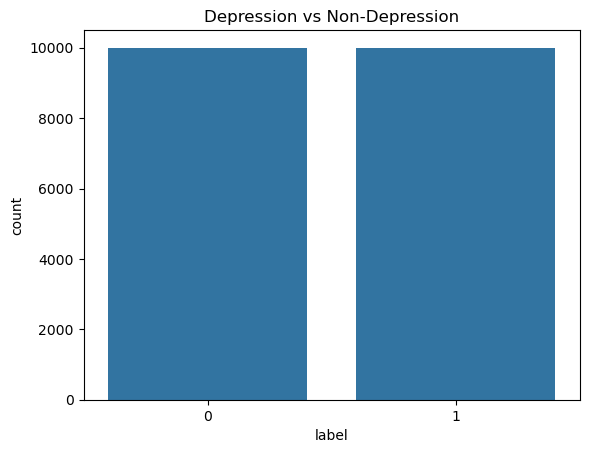

In [11]:
#4️ Exploratory Data Analysis (EDA)
#Class distribution
sns.countplot(x='label', data=df)
plt.title("Depression vs Non-Depression")
plt.show()


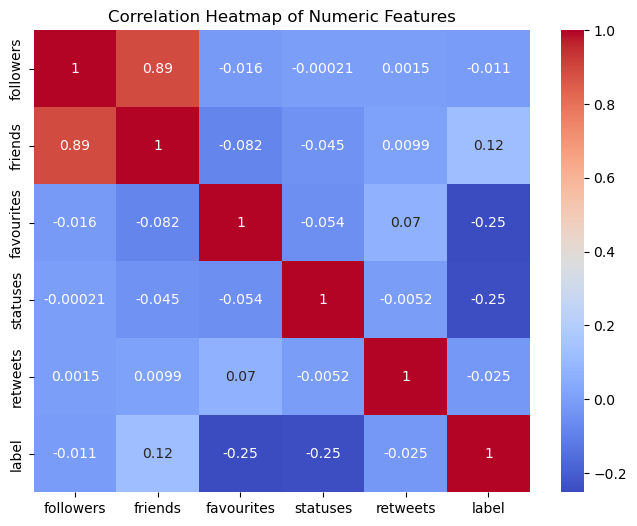

In [12]:
#Correlation heatmap
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap of Numeric Features")

plt.show()

In [13]:
#Text Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r"[^a-zA-Z\s]", "",text)
    
    custom_words = ['rt','im','dont','cant','didnt','doesnt','ive','youre']

    stop_words.update(custom_words)

    
    words = text.split()
    
    words = [word for word in words if word not in stop_words]
    
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return " ".join(words)

df['clean_text'] = df['post_text'].apply(clean_text)


In [14]:
df['clean_text']

0        year since diagnosed anxiety depression today ...
1        sunday need break planning spend little time p...
2                        awake tired need sleep brain idea
3        retro bear make perfect gift great beginner ge...
4        hard say whether packing list making life easi...
                               ...                        
19995                      day without sunshine like night
19996    borens law charge ponder trouble delegate doub...
19997    flow chart thoroughly oversold piece program d...
19998                    ship safe harbor never meant stay
19999                         black hole god dividing zero
Name: clean_text, Length: 20000, dtype: object

In [15]:
#Feature Extraction (TF-IDF)
vectorizer = TfidfVectorizer(
    max_features=7000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df['clean_text'])

y = df['label']

In [16]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 116709 stored elements and shape (20000, 7000)>

In [17]:
#comparision of post text and cleaned text

comparison = df[['post_text','clean_text']].head(10)

comparison

,post_text,clean_text
0,It's just over 2 years since I was diagnosed w...,year since diagnosed anxiety depression today ...
1,"It's Sunday, I need a break, so I'm planning t...",sunday need break planning spend little time p...
2,Awake but tired. I need to sleep but my brain ...,awake tired need sleep brain idea
3,RT @SewHQ: #Retro bears make perfect gifts and...,retro bear make perfect gift great beginner ge...
4,It’s hard to say whether packing lists are mak...,hard say whether packing list making life easi...
5,Making packing lists is my new hobby... #movin...,making packing list new hobby movinghouse
6,At what point does keeping stuff for nostalgic...,point keeping stuff nostalgic reason cross lin...
7,Currently in the finding-boxes-of-random-shit ...,currently findingboxesofrandomshit packing pha...
8,"Can't be bothered to cook, take away on the wa...",bothered cook take away way lazy
9,RT @itventsnews: ITV releases promo video for ...,itv release promo video final series downton a...


In [18]:
!pip install wordcloud

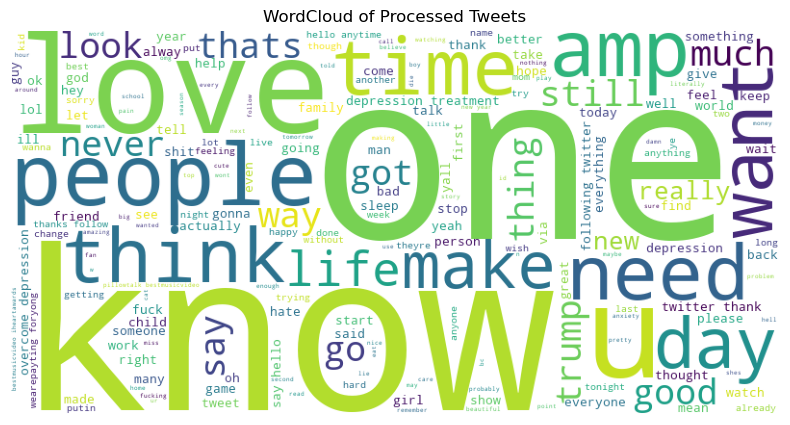

In [19]:
#Word Cloud of Processed Text
from wordcloud import WordCloud

text = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud of Processed Tweets")

plt.show()

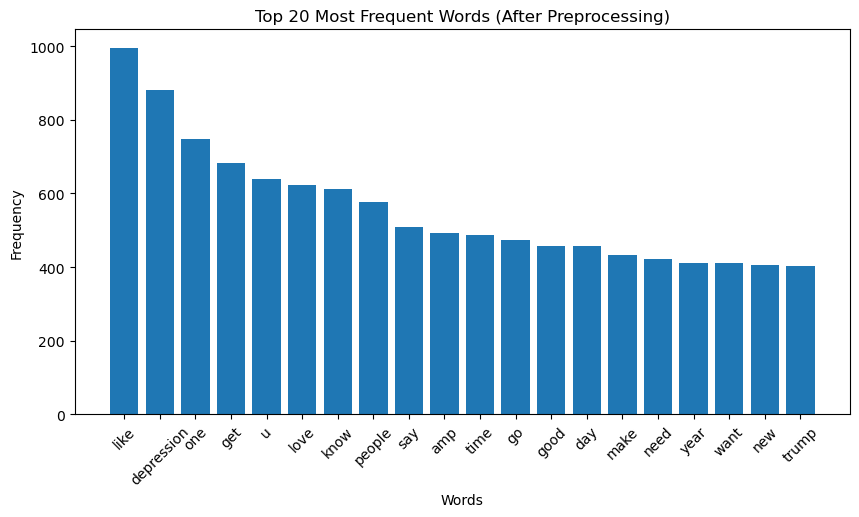

In [17]:
#Top 20 Most Frequent Words
from collections import Counter

all_words = " ".join(df['clean_text']).split()

word_freq = Counter(all_words).most_common(20)

words = [w[0] for w in word_freq]
counts = [w[1] for w in word_freq]

plt.figure(figsize=(10,5))
plt.bar(words, counts)

plt.xticks(rotation=45)

plt.title("Top 20 Most Frequent Words (After Preprocessing)")

plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

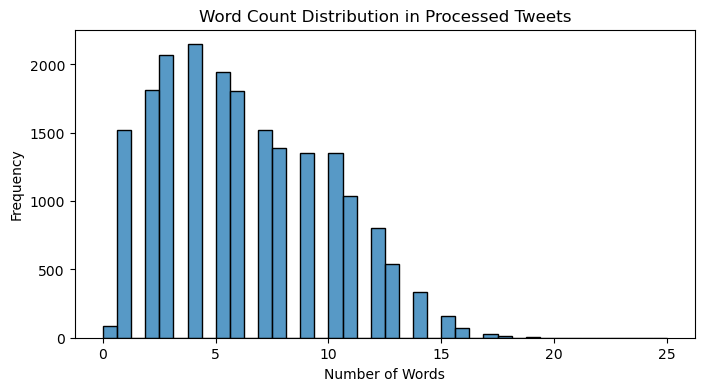

In [20]:
#Word Count Per Tweet
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,4))

sns.histplot(df['word_count'], bins=40)

plt.title("Word Count Distribution in Processed Tweets")

plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [21]:
#compare Word Counts (Before vs After)
df['original_word_count'] = df['post_text'].apply(lambda x: len(x.split()))
df['clean_word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

In [22]:
df[['original_word_count','clean_word_count']].head()

,original_word_count,clean_word_count
0,26,12
1,19,8
2,13,6
3,23,13
4,21,14


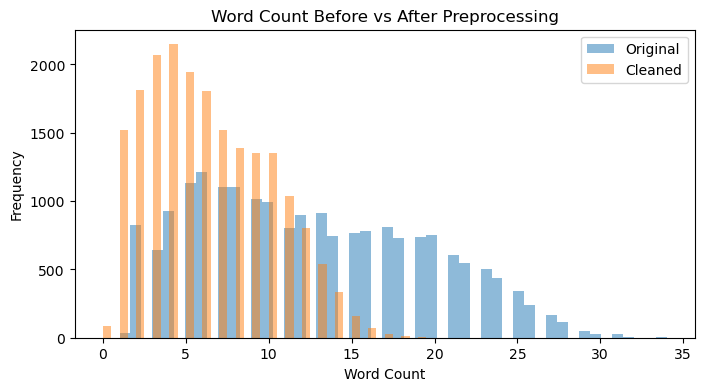

In [23]:
#Visualization of Word Count Difference
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.hist(df['original_word_count'], bins=50, alpha=0.5, label="Original")
plt.hist(df['clean_word_count'], bins=50, alpha=0.5, label="Cleaned")

plt.title("Word Count Before vs After Preprocessing")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [24]:
#Shape of TF-IDF Matrix
print(X.shape)

(20000, 7000)


In [25]:
#Train / Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (16000, 7000)
Testing Data: (4000, 7000)


In [26]:
#Model Training
#Naive Bayes (Very common for NLP)
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [27]:
nb_pred = nb_model.predict(X_test)
from sklearn.metrics import accuracy_score

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.768


In [28]:
nb_model.feature_log_prob_

array([[ -9.43303987,  -9.31895111,  -9.47416369, ...,  -8.99950118,
         -9.3971676 ,  -9.3971676 ],
       [ -9.24789699,  -9.33509923,  -9.83579722, ..., -10.1229856 ,
        -10.1229856 , -10.1229856 ]], shape=(2, 7000))

In [29]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [30]:
lr_pred = lr_model.predict(X_test)

In [31]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.75675


In [32]:
#classification report
from sklearn.metrics import classification_report

print("Naive Bayes Report")
print(classification_report(y_test, nb_pred))

print("Logistic Regression Report")
print(classification_report(y_test, lr_pred))

Naive Bayes Report
              precision    recall  f1-score   support

           0       0.78      0.75      0.76      1981
           1       0.76      0.79      0.77      2019

    accuracy                           0.77      4000
   macro avg       0.77      0.77      0.77      4000
weighted avg       0.77      0.77      0.77      4000

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.75      0.77      0.76      1981
           1       0.77      0.74      0.76      2019

    accuracy                           0.76      4000
   macro avg       0.76      0.76      0.76      4000
weighted avg       0.76      0.76      0.76      4000



In [33]:
#pickle file
import pickle

with open('nb_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

In [35]:
#pipeline
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('tfidf', vectorizer),
    ('model', nb_model)
])
X = df['clean_text']
y = df['label']
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [36]:
prediction = pipeline.predict(["i feel very happy"])
print(prediction)

[1]


In [37]:
import pickle

with open('pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

In [38]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'nb_model.pkl', 'pipeline.pkl', 'project1.ipynb', 'Untitled.ipynb', 'vectorizer.pkl']


In [39]:
import os
print(os.getcwd())


C:\Users\surai\project
